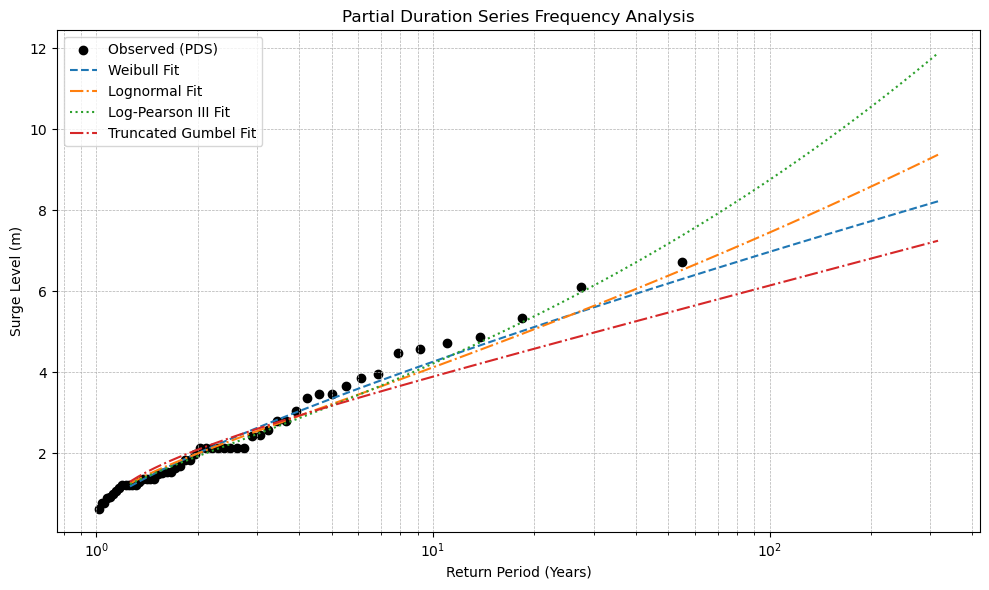

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min, lognorm, pearson3, gumbel_r

# Step 1: Read CSV file
filename = r"D:\Phd Research\Frequency Analysis\surge_height.csv"
df = pd.read_csv(filename)

# Step 2: Clean time and surge
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)
df = df.drop_duplicates(subset='time')
df = df.dropna()

# Step 3: Apply threshold for PDS
threshold = 0.43
df_pds = df[df["surge"] > threshold]

# Sort peaks
df_pds = df_pds.sort_values(by="surge", ascending=False).reset_index(drop=True)
n_events = len(df_pds)

# Exceedance probability
df_pds["Rank"] = np.arange(1, n_events+1)
df_pds["Exceedance_Probability"] = df_pds["Rank"] / (n_events + 1)
df_pds["Return_Period"] = 1 / df_pds["Exceedance_Probability"]

# Step 4: Fit distributions
params_weibull = weibull_min.fit(df_pds["surge"])
params_lognorm = lognorm.fit(df_pds["surge"], floc=0)
log_surge = np.log10(df_pds["surge"])
params_lp3 = pearson3.fit(log_surge)
params_gumbel = gumbel_r.fit(df_pds["surge"])

# Step 5: Prediction
T = np.logspace(0.1, 2.5, 100)
P = 1/T

weibull_quantiles = weibull_min.ppf(1-P, *params_weibull)
lognorm_quantiles = lognorm.ppf(1-P, *params_lognorm)
lp3_quantiles = 10**(pearson3.ppf(1-P, *params_lp3))
gumbel_quantiles = gumbel_r.ppf(1-P, *params_gumbel)

# Step 6: Plot
plt.figure(figsize=(10,6))
plt.scatter(df_pds["Return_Period"], df_pds["surge"], color='black', label="Observed (PDS)", marker="o")

plt.plot(T, weibull_quantiles, label="Weibull Fit", linestyle="--")
plt.plot(T, lognorm_quantiles, label="Lognormal Fit", linestyle="-.")
plt.plot(T, lp3_quantiles, label="Log-Pearson III Fit", linestyle=":")
plt.plot(T, gumbel_quantiles, label="Truncated Gumbel Fit", linestyle="-.")

plt.xscale("log")
plt.xlabel("Return Period (Years)")
plt.ylabel("Surge Level (m)")
plt.title("Partial Duration Series Frequency Analysis")
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [03:56<00:00, 21.16it/s]


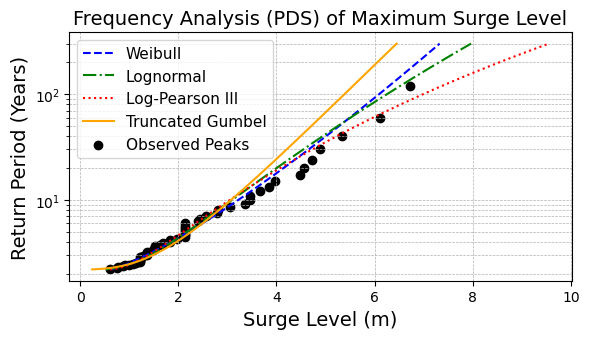

In [29]:
# ===========================
# Full PDS + Monte Carlo + Plotting Code
# ===========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min, lognorm, pearson3, gumbel_r
from tqdm import tqdm

# Step 1: Load Data
filename = r"D:\Phd Research\Frequency Analysis\surge_height.csv"
df = pd.read_csv(filename)

# Step 2: Clean time and surge
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)
df = df.drop_duplicates(subset='time')
df = df.dropna()

# Step 3: PDS settings
threshold = 0.43
record_length = 118  # years

df_pds = df[df["surge"] > threshold]
df_pds = df_pds.sort_values(by="surge", ascending=False).reset_index(drop=True)
n_events = len(df_pds)

# Rate of exceedances
lambda_rate = n_events / record_length

# Exceedance probability
df_pds["Rank"] = np.arange(1, n_events+1)
df_pds["Exceedance_Probability"] = df_pds["Rank"] / (n_events + 1)
df_pds["Return_Period"] = 1 / (lambda_rate * df_pds["Exceedance_Probability"])

# Step 4: Fit Distributions
params_weibull = weibull_min.fit(df_pds["surge"])
params_lognorm = lognorm.fit(df_pds["surge"], floc=0)
log_surge = np.log10(df_pds["surge"])
params_lp3 = pearson3.fit(log_surge)
params_gumbel = gumbel_r.fit(df_pds["surge"])

# Step 5: Define Target Return Periods
target_T = np.array([5, 10, 20, 50, 100])
P_target = 1 / (lambda_rate * target_T)

# Best-fit Quantiles at Target Return Periods
weibull_vals = weibull_min.ppf(1-P_target, *params_weibull)
lognorm_vals = lognorm.ppf(1-P_target, *params_lognorm)
lp3_vals = 10**(pearson3.ppf(1-P_target, *params_lp3))
gumbel_vals = gumbel_r.ppf(1-P_target, *params_gumbel)

# Step 6: Monte Carlo Simulation
n_simulations = 5000
mc_weibull = np.zeros((n_simulations, len(target_T)))
mc_lognorm = np.zeros((n_simulations, len(target_T)))
mc_lp3 = np.zeros((n_simulations, len(target_T)))
mc_gumbel = np.zeros((n_simulations, len(target_T)))

for i in tqdm(range(n_simulations)):
    # Resample
    sample_weibull = weibull_min.rvs(*params_weibull, size=n_events)
    sample_lognorm = lognorm.rvs(*params_lognorm, size=n_events)
    sample_lp3 = 10**(pearson3.rvs(*params_lp3, size=n_events))
    sample_gumbel = gumbel_r.rvs(*params_gumbel, size=n_events)
    
    # Refit
    p_weibull = weibull_min.fit(sample_weibull)
    p_lognorm = lognorm.fit(sample_lognorm, floc=0)
    p_lp3 = pearson3.fit(np.log10(sample_lp3))
    p_gumbel = gumbel_r.fit(sample_gumbel)
    
    # Store quantiles
    mc_weibull[i,:] = weibull_min.ppf(1-P_target, *p_weibull)
    mc_lognorm[i,:] = lognorm.ppf(1-P_target, *p_lognorm)
    mc_lp3[i,:] = 10**(pearson3.ppf(1-P_target, *p_lp3))
    mc_gumbel[i,:] = gumbel_r.ppf(1-P_target, *p_gumbel)

# Step 7: Calculate Confidence Intervals
ci_lower_weibull = np.percentile(mc_weibull, 2.5, axis=0)
ci_upper_weibull = np.percentile(mc_weibull, 97.5, axis=0)

ci_lower_lognorm = np.percentile(mc_lognorm, 2.5, axis=0)
ci_upper_lognorm = np.percentile(mc_lognorm, 97.5, axis=0)

ci_lower_lp3 = np.percentile(mc_lp3, 2.5, axis=0)
ci_upper_lp3 = np.percentile(mc_lp3, 97.5, axis=0)

ci_lower_gumbel = np.percentile(mc_gumbel, 2.5, axis=0)
ci_upper_gumbel = np.percentile(mc_gumbel, 97.5, axis=0)

# Step 8: Prepare Fine Plotting Curves
T_plot = np.logspace(np.log10(1.01), np.log10(300), 300)
P_plot = 1 / (lambda_rate * T_plot)  # Adjusted exceedance probability for PDS

weibull_curve = weibull_min.ppf(1-P_plot, *params_weibull)
lognorm_curve = lognorm.ppf(1-P_plot, *params_lognorm)
lp3_curve = 10**(pearson3.ppf(1-P_plot, *params_lp3))
gumbel_curve = gumbel_r.ppf(1-P_plot, *params_gumbel)

# Step 9: Plotting
fig, ax1 = plt.subplots(figsize=(6,3.5))

# Primary Y-axis: Return Period
ax1.set_xlabel("Surge Level (m)", fontsize=14)
ax1.set_ylabel("Return Period (Years)", fontsize=14)
ax1.set_xscale('linear')
ax1.set_yscale('log')
ax1.grid(True, which="both", ls="--", lw=0.5)

# Plot fitted curves
ax1.plot(weibull_curve, T_plot, label="Weibull", linestyle="--", color='blue')
ax1.plot(lognorm_curve, T_plot, label="Lognormal", linestyle="-.", color='green')
ax1.plot(lp3_curve, T_plot, label="Log-Pearson III", linestyle=":", color='red')
ax1.plot(gumbel_curve, T_plot, label="Truncated Gumbel", linestyle="-", color='orange')

# Plot observed PDS points
ax1.scatter(df_pds["surge"], df_pds["Return_Period"], color='black', marker='o', label="Observed Peaks")

# No secondary axis
ax1.legend(loc="upper left", fontsize=11)
plt.title("Frequency Analysis (PDS) of Maximum Surge Level", fontsize=14)
plt.tight_layout()
plt.show()


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [04:49<00:00, 17.27it/s]


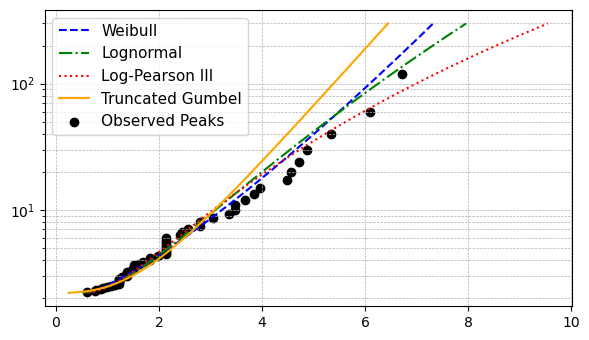

In [1]:
# ===========================
# Full PDS + Monte Carlo + Plotting Code
# ===========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min, lognorm, pearson3, gumbel_r
from tqdm import tqdm

# Step 1: Load Data
filename = r"D:\Phd Research\Frequency Analysis\surge_height.csv"
df = pd.read_csv(filename)

# Step 2: Clean time and surge
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)
df = df.drop_duplicates(subset='time')
df = df.dropna()

# Step 3: PDS settings
threshold = 0.43
record_length = 118  # years

df_pds = df[df["surge"] > threshold]
df_pds = df_pds.sort_values(by="surge", ascending=False).reset_index(drop=True)
n_events = len(df_pds)

# Rate of exceedances
lambda_rate = n_events / record_length

# Exceedance probability
df_pds["Rank"] = np.arange(1, n_events+1)
df_pds["Exceedance_Probability"] = df_pds["Rank"] / (n_events + 1)
df_pds["Return_Period"] = 1 / (lambda_rate * df_pds["Exceedance_Probability"])

# Step 4: Fit Distributions
params_weibull = weibull_min.fit(df_pds["surge"])
params_lognorm = lognorm.fit(df_pds["surge"], floc=0)
log_surge = np.log10(df_pds["surge"])
params_lp3 = pearson3.fit(log_surge)
params_gumbel = gumbel_r.fit(df_pds["surge"])

# Step 5: Define Target Return Periods
target_T = np.array([5, 10, 20, 50, 100])
P_target = 1 / (lambda_rate * target_T)

# Best-fit Quantiles at Target Return Periods
weibull_vals = weibull_min.ppf(1-P_target, *params_weibull)
lognorm_vals = lognorm.ppf(1-P_target, *params_lognorm)
lp3_vals = 10**(pearson3.ppf(1-P_target, *params_lp3))
gumbel_vals = gumbel_r.ppf(1-P_target, *params_gumbel)

# Step 6: Monte Carlo Simulation
n_simulations = 5000
mc_weibull = np.zeros((n_simulations, len(target_T)))
mc_lognorm = np.zeros((n_simulations, len(target_T)))
mc_lp3 = np.zeros((n_simulations, len(target_T)))
mc_gumbel = np.zeros((n_simulations, len(target_T)))

for i in tqdm(range(n_simulations)):
    # Resample
    sample_weibull = weibull_min.rvs(*params_weibull, size=n_events)
    sample_lognorm = lognorm.rvs(*params_lognorm, size=n_events)
    sample_lp3 = 10**(pearson3.rvs(*params_lp3, size=n_events))
    sample_gumbel = gumbel_r.rvs(*params_gumbel, size=n_events)
    
    # Refit
    p_weibull = weibull_min.fit(sample_weibull)
    p_lognorm = lognorm.fit(sample_lognorm, floc=0)
    p_lp3 = pearson3.fit(np.log10(sample_lp3))
    p_gumbel = gumbel_r.fit(sample_gumbel)
    
    # Store quantiles
    mc_weibull[i,:] = weibull_min.ppf(1-P_target, *p_weibull)
    mc_lognorm[i,:] = lognorm.ppf(1-P_target, *p_lognorm)
    mc_lp3[i,:] = 10**(pearson3.ppf(1-P_target, *p_lp3))
    mc_gumbel[i,:] = gumbel_r.ppf(1-P_target, *p_gumbel)

# Step 7: Calculate Confidence Intervals
ci_lower_weibull = np.percentile(mc_weibull, 2.5, axis=0)
ci_upper_weibull = np.percentile(mc_weibull, 97.5, axis=0)

ci_lower_lognorm = np.percentile(mc_lognorm, 2.5, axis=0)
ci_upper_lognorm = np.percentile(mc_lognorm, 97.5, axis=0)

ci_lower_lp3 = np.percentile(mc_lp3, 2.5, axis=0)
ci_upper_lp3 = np.percentile(mc_lp3, 97.5, axis=0)

ci_lower_gumbel = np.percentile(mc_gumbel, 2.5, axis=0)
ci_upper_gumbel = np.percentile(mc_gumbel, 97.5, axis=0)

# Step 8: Prepare Fine Plotting Curves
T_plot = np.logspace(np.log10(1.01), np.log10(300), 300)
P_plot = 1 / (lambda_rate * T_plot)  # Adjusted exceedance probability for PDS

weibull_curve = weibull_min.ppf(1-P_plot, *params_weibull)
lognorm_curve = lognorm.ppf(1-P_plot, *params_lognorm)
lp3_curve = 10**(pearson3.ppf(1-P_plot, *params_lp3))
gumbel_curve = gumbel_r.ppf(1-P_plot, *params_gumbel)

# Step 9: Plotting
fig, ax1 = plt.subplots(figsize=(6,3.5))

# Primary Y-axis: Return Period
# ax1.set_xlabel("Surge Level (m)", fontsize=14)
# ax1.set_ylabel("Return Period (Years)", fontsize=14)
ax1.set_xscale('linear')
ax1.set_yscale('log')
ax1.grid(True, which="both", ls="--", lw=0.5)

# Plot fitted curves
ax1.plot(weibull_curve, T_plot, label="Weibull", linestyle="--", color='blue')
ax1.plot(lognorm_curve, T_plot, label="Lognormal", linestyle="-.", color='green')
ax1.plot(lp3_curve, T_plot, label="Log-Pearson III", linestyle=":", color='red')
ax1.plot(gumbel_curve, T_plot, label="Truncated Gumbel", linestyle="-", color='orange')

# Plot observed PDS points
ax1.scatter(df_pds["surge"], df_pds["Return_Period"], color='black', marker='o', label="Observed Peaks")

# No secondary axis
ax1.legend(loc="upper left", fontsize=11)
# plt.title("Frequency Analysis (PDS) of Maximum Surge Level", fontsize=14)
plt.tight_layout()
plt.show()
